In [30]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#### **Synthetically Data Generation**
##### **Using Logit Function, the target variable is generated**

In [31]:

np.random.seed(42)
sns.set(style="whitegrid")

# Simulate customer data
n = 200
time_spent = np.random.normal(20, 5, n)
coffee_cost = np.random.normal(3.5, 0.5, n)
age = np.random.normal(30, 10, n)

# Generate muffin purchase (1 or 0) using logistic function
prob_muffin = 1 / (1 + np.exp(-(-5 + 0.1*time_spent + 0.8*coffee_cost - 0.03*age)))
bought_muffin = np.random.binomial(1, prob_muffin)

# Create a DataFrame
df = pd.DataFrame({
    'Time_Spent': time_spent,
    'Coffee_Cost': coffee_cost,
    'Age': age,
    'Bought_Muffin': bought_muffin
})
df

,Time_Spent,Coffee_Cost,Age,Bought_Muffin
0,22.483571,3.678894,14.055723,0
1,19.308678,3.780392,24.006250,1
2,23.238443,4.041526,30.052437,1
3,27.615149,4.026901,30.469806,0
4,18.829233,2.811165,25.499345,0
...,...,...,...,...
195,21.926587,3.265412,24.899836,1
196,15.580713,2.643433,27.301251,0
197,20.768626,4.176936,20.212363,0
198,20.291044,3.442730,25.557067,0


#### Scale the independent variables

In [32]:
X = df[['Time_Spent', 'Coffee_Cost', 'Age']]
Y = df['Bought_Muffin'].values

# Normalize
X = (X - X.mean()) / X.std()

# Add intercept
X = np.c_[np.ones(X.shape[0]), X]
X

array([[ 1.00000000e+00,  5.77317785e-01,  2.75499619e-01,
        -1.51781581e+00],
       [ 1.00000000e+00, -1.04718503e-01,  4.81169712e-01,
        -5.16799091e-01],
       [ 1.00000000e+00,  7.39480782e-01,  1.01031328e+00,
         9.14435572e-02],
       [ 1.00000000e+00,  1.67969307e+00,  9.80678954e-01,
         1.33430611e-01],
       [ 1.00000000e+00, -2.07713852e-01, -1.48280841e+00,
        -3.66594617e-01],
       [ 1.00000000e+00, -2.07696218e-01, -1.03717252e+00,
         7.12751559e-01],
       [ 1.00000000e+00,  1.74003971e+00,  4.34818058e-01,
        -9.87851037e-01],
       [ 1.00000000e+00,  8.68101284e-01,  4.33552292e-01,
        -5.70644420e-02],
       [ 1.00000000e+00, -4.60474348e-01,  4.34830641e-01,
         2.07185080e-01],
       [ 1.00000000e+00,  6.26561284e-01,  3.81646278e+00,
         6.03690673e-01],
       [ 1.00000000e+00, -4.53968797e-01,  4.91408765e-01,
         8.02048538e-01],
       [ 1.00000000e+00, -4.56452203e-01,  1.06351915e+00,
      

#### defining function for the gradient descent

In [24]:
# Sigmoid
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Log Loss (Cost)
def compute_cost(X, Y, theta):
    m = len(Y)
    predictions = sigmoid(X.dot(theta))
    cost = - (1/m) * np.sum(Y*np.log(predictions) + (1 - Y)*np.log(1 - predictions))
    return cost

# Gradient Descent
def gradient_descent(X, Y, theta, learning_rate, iterations):
    m = len(Y)
    cost_history = []
    
    for _ in range(iterations):
        predictions = sigmoid(X.dot(theta))
        gradient = (1/m) * X.T.dot(predictions - Y)
        theta -= learning_rate * gradient
        cost_history.append(compute_cost(X, Y, theta))
    
    return theta, cost_history


In [25]:
theta = np.random.randn(X.shape[1])
learning_rate = 0.1
iterations = 1000

theta, cost_history = gradient_descent(X, Y, theta, learning_rate, iterations)


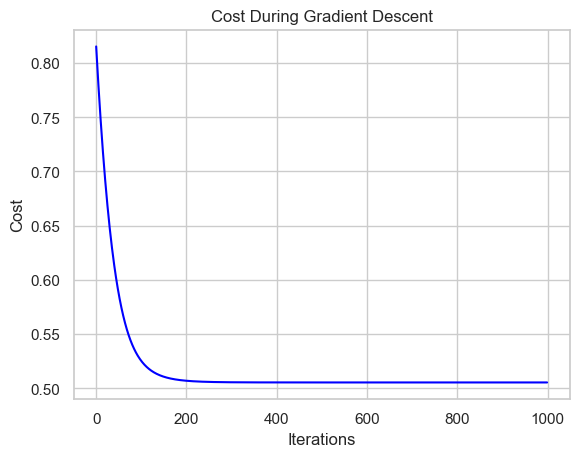

In [26]:
plt.plot(range(iterations), cost_history, color='blue')
plt.title("Cost During Gradient Descent")
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.show()


#### Prediction made using Gradient Descent

In [29]:
# Original stats
X_mean = df[['Time_Spent', 'Coffee_Cost', 'Age']].mean().values
X_std = df[['Time_Spent', 'Coffee_Cost', 'Age']].std().values

# New customer: 60 mins, $4 coffee, age 35
new_customer = (np.array([60, 4, 35]) - X_mean) / X_std
#new_customer = (np.array([20, 4, 55]) - X_mean) / X_std
new_customer = np.concatenate(([1], new_customer))  # add intercept

# Prediction function
def predict(X, theta):
    return sigmoid(X.dot(theta)) >= 0.5

# Predict
result = predict(new_customer, theta)
print("Prediction:", "🧁 Muffin Bought!" if result else "🚫 No Muffin.")


Prediction: 🧁 Muffin Bought!
